In [ ]:
# 목표: 흑백 사진을 분류하기 위해 여러가지 아이디어를 내면서 비지도 학습과 군집 알고리즘에 대해 이해합시다

# 핵심키워드 : 비지도 학습, 히스토그램, 군집

# 데이터셋 : fruits_300.npy

# --------------------------------------------------

# 목표: k-평균 알고리즘의 작동 방식을 이해하고 과일 사진을 자동으로 모으는 비지도 학습 모델을 만들어 봅시다

# 핵심키워드 : k-평균, 클러스터추정, 엘보우 방법
# 핵심 패키지와 함수 : KMeans,

# 데이터셋 : fruits_300.npy

In [ ]:
# 해결해야할 문제
# - 과일사진 들을 '종류'별로 모을수 있을까?
# - 사진에 대한 정답 (타겟, 레이블) 을 알지 못하는데?


# 비지도 학습
Unsupervised Learning

target값 (y, 레이블) 없는 머신러닝 알고리즘

# ■ 군집 알고리즘

# 데이터 준비

In [ ]:
# 과일 사진 데이터 준비

# 사과, 바나나, 파인애플 을 담고 있는 grayscale 이미지
# 넘파이 저장포맷 npy 형태

# 사과, 바나나, 파인애플 이 각각 100개씩 들어있다
#   처음 100개는 사과, 그 다름 100개는 파인애플, 마지막 100개는 바나나

# 데이터 출처
#    https://www.kaggle.com/datasets/moltean/fruits



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
base_path = r'F:\KDT2508\dataset'

In [4]:
file_path = os.path.join(base_path, 'fruits_300.npy')

# numpy 불러오기
fruits = np.load(file_path)

fruits.shape

(300, 100, 100)

In [11]:
#  (샘플개수, height(행), width(열))
#    (300,   100,    100)


# ↓ '첫번째 이미지'의 '첫번째 행' 데이터를 확인해보자.

fruits[0, 0, :]


array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   2,   1,   2,   2,   2,   2,   2,   2,   1,   1,
         1,   1,   1,   1,   1,   1,   2,   3,   2,   1,   2,   1,   1,
         1,   1,   2,   1,   3,   2,   1,   3,   1,   4,   1,   2,   5,
         5,   5,  19, 148, 192, 117,  28,   1,   1,   2,   1,   4,   1,
         1,   3,   1,   1,   1,   1,   1,   2,   2,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1], dtype=uint8)

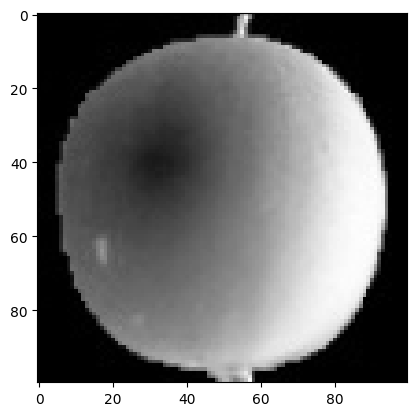

In [13]:
# ↑ grayscale 이미지이므로 0 ~ 255 까지의 정수값을 가집니다.

# 첫번째 이미지를 시각화 하고 위 숫자 값과 비교해보겠습니다.

plt.imshow(fruits[0], cmap='gray')
plt.show()

In [ ]:
# 일반적으로 흑백 샘플 이미지는 바탕이 밝고 물체 (여기서는 사과) 가 짙은 색입니다.
# 반면 위 이미지는 배경이 검정색(0) 이고 물체가 밝은 색이다.
# 사실 이 흑백 이미지는 사진으로 찍은 이미지를 넘파이 배열로 변환할 때 '반전(invert)'시킨 것입니다

# 왜?

![](https://image-res.xtool.com/resource/xtool/community/attachment/xtool-community/d52628b5-822d-472f-8f43-11c38312ff13/invert.png?x-oss-process=image/resize,m_fill,w_800,h_600,limit_0/interlace,1/format,webp)

In [ ]:
# 이미지의 주 관심대상은 '바탕' 아니라 '사과'다
# 만약에 바탕이 흰색이면, 각종 연산에서 255에 가까운 바탕에 집중하게 될것이다.
# 그래서 바탕을 검게!,  사과를 밝게!  반전(invert) 하여 다룹니다


# ↓ cmap='gray_r'  로 지정하면 다시 반전하여 우리 눈에 보기 좋게 출력합니다

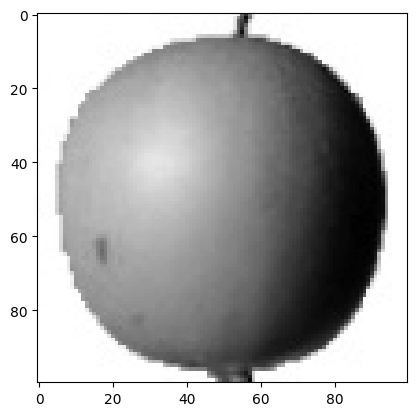

In [15]:
plt.imshow(fruits[0], cmap='gray_r')  # gray_r 반전하여 출력
plt.show()

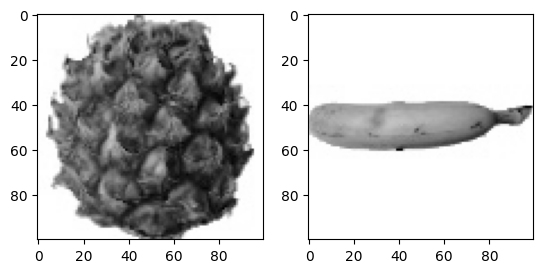

In [18]:
# 이 데이터는 사과, 바나나, 파인애플이 각각 100개씩 들어있습니다.
# 파인애플과 바나나의 첫 이미지도 각각 출력해보기

fig, axs = plt.subplots(1, 2)
axs[0].imshow(fruits[100], cmap='gray_r')
axs[1].imshow(fruits[200], cmap='gray_r')
plt.show()


In [ ]:
# 과연 어떻게 사진을 분류해 낼수 있을까?
# 아이디어! => 사진의 픽셀값을 모두 '평균' 내면 비슷한 과일들끼리 모을수 있을까?


# 픽셀값 분석하기

In [ ]:
# step 1. 사용하기 쉽게 fruits 데이터를 사과, 파인애플, 바나나로 각각 나누어 봅시다.
# step 2. (100, 100) -> (10000, ) 으로 1차원 배열로 만들기. => 배열계산에 편리해진다.
# step 3. 픽셀의 평균값 계산하기

In [21]:
# 사용하기 쉽게 fruits 데이터를 사과, 파인애플, 바나나로 각각 나누어 봅시다.

apple = fruits[:100].reshape(-1,100*100)
pineapple = fruits[100:200].reshape(-1,100*100)
banana = fruits[200:].reshape(-1,100*100)

In [22]:
# 배열 크기 확인
apple.shape


(100, 10000)

In [28]:
# 픽셀의 평균값 알아보자.
# 100개의 사과 이미지의 픽셀 평균값들
apple.mean(axis=1)

array([ 88.3346,  97.9249,  87.3709,  98.3703,  92.8705,  82.6439,
        94.4244,  95.5999,  90.681 ,  81.6226,  87.0578,  95.0745,
        93.8416,  87.017 ,  97.5078,  87.2019,  88.9827, 100.9158,
        92.7823, 100.9184, 104.9854,  88.674 ,  99.5643,  97.2495,
        94.1179,  92.1935,  95.1671,  93.3322, 102.8967,  94.6695,
        90.5285,  89.0744,  97.7641,  97.2938, 100.7564,  90.5236,
       100.2542,  85.8452,  96.4615,  97.1492,  90.711 , 102.3193,
        87.1629,  89.8751,  86.7327,  86.3991,  95.2865,  89.1709,
        96.8163,  91.6604,  96.1065,  99.6829,  94.9718,  87.4812,
        89.2596,  89.5268,  93.799 ,  97.3983,  87.151 ,  97.825 ,
       103.22  ,  94.4239,  83.6657,  83.5159, 102.8453,  87.0379,
        91.2742, 100.4848,  93.8388,  90.8568,  97.4616,  97.5022,
        82.446 ,  87.1789,  96.9206,  90.3135,  90.565 ,  97.6538,
        98.0919,  93.6252,  87.3867,  84.7073,  89.1135,  86.7646,
        88.7301,  86.643 ,  96.7323,  97.2604,  81.9424,  87.1

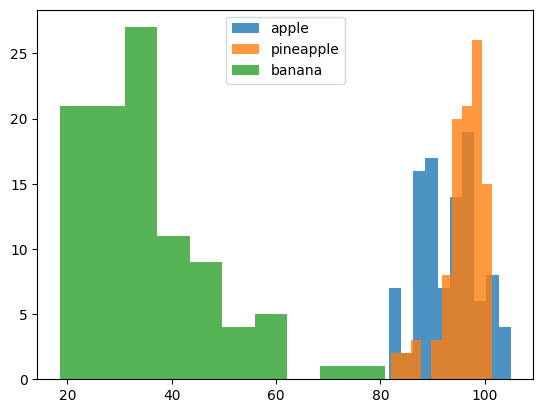

In [29]:
# 히스토그램 을 그려보면 평균값이 어떻게 분포되어 있는지 한눈에 잘 볼수 있습니다

plt.hist(np.mean(apple, axis=1), alpha=0.8)
plt.hist(np.mean(pineapple, axis=1), alpha=0.8)
plt.hist(np.mean(banana, axis=1), alpha=0.8)
plt.legend(['apple', 'pineapple', 'banana'])
plt.show()


In [32]:
# ↑바나나는  사과,파인애플과는 확실히 구분되나
# 사과 와 파인애플은 펵셀평균값으로는 구분하기 쉽지 않겠다.

# 아이디어2)
#  샘플의 평균값이 아니라, 픽셀별 평균값을 비교해보면 어떨까?
#     <= 세 과일의 '모양' 이 다르니 픽셀값이 높은 위치도 다르지 않을까?


# ↓픽셀의 평균을 계산하는 것도 간단합니다. axis=0 으로 지정하면 됩니다!

In [31]:
# 이미지 한장당 100 x 100 = 10000 픽셀 , 각 픽셀별 평균.
np.mean(apple, axis=0)


array([1.01, 1.01, 1.01, ..., 1.  , 1.  , 1.  ], shape=(10000,))

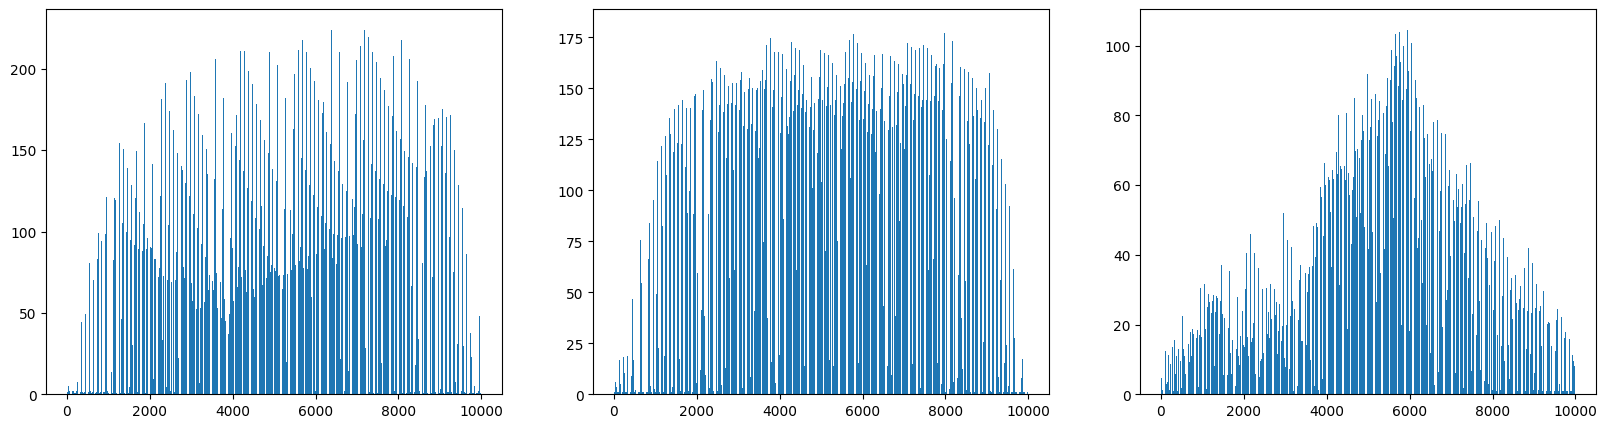

In [30]:
# 히스토그램 시각화

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

axs[0].bar(range(10000), np.mean(apple, axis=0))
axs[1].bar(range(10000), np.mean(pineapple, axis=0))
axs[2].bar(range(10000), np.mean(banana, axis=0))

plt.show()

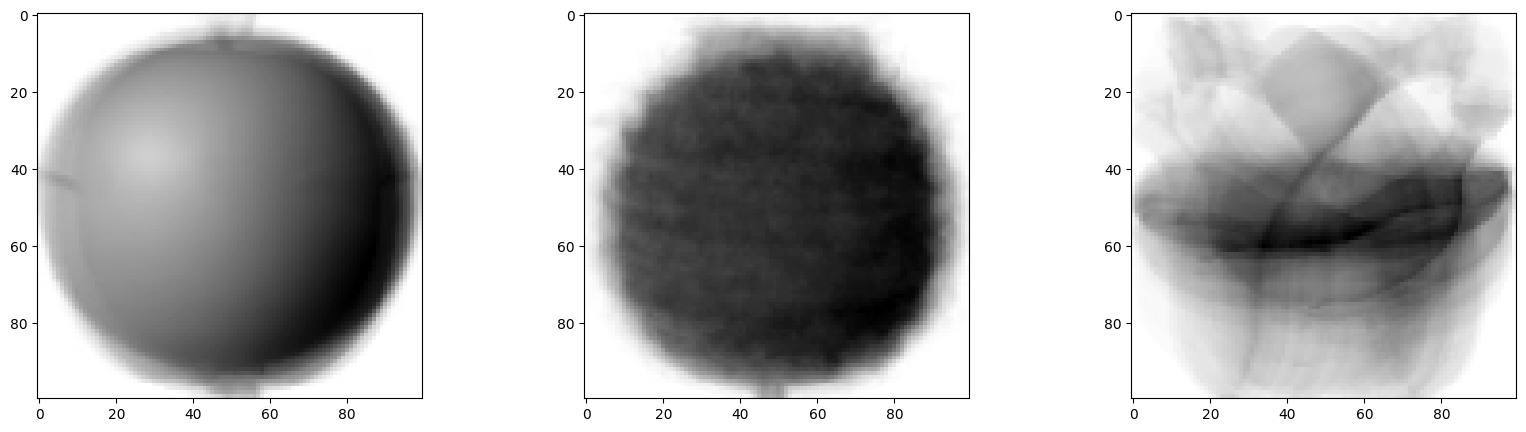

In [33]:
# 픽셀 평균값을 100 x 100 크기로 바꿔서 이미지처럼 출력하여 위 그래프와 비교하면 더 좋습니다.
# 픽셀을 평균낸 이미지를 모든 사진을 합쳐 놓은 대표 이미지로 생각할수 있습니다

apple_mean = np.mean(apple, axis=0).reshape(100,100)
pineapple_mean = np.mean(pineapple, axis=0).reshape(100,100)
banana_mean = np.mean(banana, axis=0).reshape(100,100)

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(apple_mean, cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean, cmap='gray_r')
plt.show()


# 평균값과 가까운 사진 고르기

In [34]:
# 사과 사진의 평균값인 apple_mean 과 가장 가까운 사진을 골라봅니다.
# 이때 '절대값 오차' 를 사용해보자.
# fruits 배열에 있는 모든 샘플에서 apple_mean 을 뺀 절대값의 평균을 계산하면 된다.

abs_diff = np.abs(fruits - apple_mean)

abs_diff.shape

(300, 100, 100)

In [35]:
# ↑ abs_diff 는 (300, 100, 100) 크기의 배열입니다.
# 따라서 각 샘플에 대한 오차 평균을 구하기 위해 axis 에 두번째, 세번째 차원을 모두 지정했습니다.

abs_mean = np.mean(abs_diff, axis=(1,2))
print(abs_mean.shape)

# ↓ 이렇게 계산한 abs_mean 은 각 샘플의 오차 평균이므로 크기가 (300, ) 인 1차원 배열입니다
abs_mean

(300,)


array([17.37576 , 13.508874, 17.183394, 15.68311 , 17.983306, 20.565392,
       16.795812, 16.144276, 19.611994, 21.32059 , 16.454222, 16.590134,
       13.37039 , 17.23263 , 15.92806 , 15.496638, 18.582212, 16.48196 ,
       27.651556, 19.7871  , 20.826912, 16.417934, 17.059946, 15.904296,
       15.086176, 19.371364, 24.076362, 14.777732, 19.20517 , 20.805182,
       14.797906, 18.658418, 15.973216, 13.04259 , 18.381052, 16.59904 ,
       16.288504, 18.960586, 13.88574 , 16.497594, 18.40376 , 19.174642,
       29.096702, 18.40849 , 28.223962, 21.42994 , 19.740466, 15.590532,
       13.082678, 18.765996, 14.391198, 21.464746, 26.261028, 15.887148,
       18.568706, 16.410426, 17.108034, 13.178824, 18.199846, 13.503056,
       20.845032, 16.898184, 22.81774 , 18.99896 , 19.102706, 16.636216,
       14.845644, 19.357872, 14.778086, 14.468082, 13.085526, 15.946606,
       20.42774 , 16.241996, 13.720382, 18.416166, 15.229106, 16.411342,
       13.47148 , 20.050622, 17.296816, 21.071312, 

In [36]:
# np.argsort() 함수는 작은 것에서 큰 순서대로 나열한 abs_mean 배열의 '인덱스'를 반환
np.argsort(abs_mean)


array([ 33,  48,  70,  57,  87,  12,  78,  59,   1,  74,  86,  38,  50,
        92,  69,  27,  68,  30,  66,  24,  76,  98,  15,  84,  47,  90,
         3,  94,  53,  23,  14,  71,  32,   7,  73,  36,  55,  77,  21,
        10,  17,  39,  99,  95,  11,  35,  65,   6,  61,  22,  56,  89,
         2,  13,  80,   0,  97,   4,  58,  34,  40,  43,  75,  82,  54,
        16,  31,  49,  93,  37,  63,  64,  41,  28,  67,  25,  96,   8,
        83,  46,  19,  79,  72,   5,  85,  29,  20,  60,  81,   9,  45,
        51,  88,  62,  91,  26,  52,  18,  44,  42, 110, 120, 141, 112,
       124, 102, 109, 192, 140, 142, 183, 117, 101, 128, 179, 159, 184,
       154, 188, 139, 165, 119, 158, 100, 111, 191, 107, 137, 182, 175,
       129, 148, 155, 103, 157, 181, 193, 121, 177, 186, 106, 174, 127,
       164, 156, 185, 189, 133, 152, 118, 169, 144, 136, 104, 105, 161,
       149, 145, 166, 160, 131, 162, 198, 150, 122, 167, 138, 176, 115,
       147, 151, 190, 135, 172, 187, 180, 113, 125, 130, 163, 17

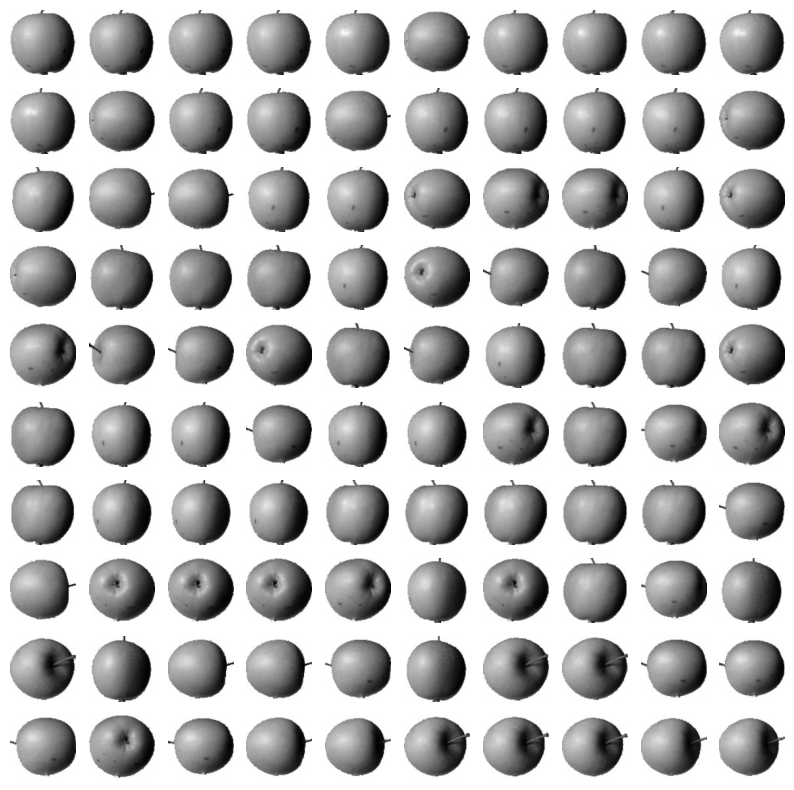

In [37]:
#  ↑ 초반 100개를 시각화 해보자 과연 사과를 잘 분류 해 냈을까?

apple_index = np.argsort(abs_mean)[:100]  # 초반 100개

fig, axs = plt.subplots(10, 10, figsize=(10,10))  # ※ figsize 기본값은 (8,6) 입니다
for i in range(10):
    for j in range(10):
        axs[i, j].imshow(fruits[apple_index[i*10+j]],cmap='gray_r')
        axs[i, j].axis('off')  # axis('off') : 좌표축 제거.  깔끔하게 이미지만 그리기 위해 !
plt.show()

## 군집(clustering), 클러스터(cluster)

`군집 (clustering) : 비슷한 샘플끼리 그룹으로 모으는 작업`

`클러스터 (cluster) : 군집 알고리즘에서 만든 그룹`

# ■ K-means (k-평균) 알고리즘

In [ ]:
# k-평균 (k-means) 군집 알고리즘을 사용하면 '평균값' 을 자동으로 찾아줍니다.

# '평균값' 은 클러스터의 중심에 위치하기 때문에
#     '클러스터 중심 (cluster center)' 또는 센트로이드 (centroid) 라고도 한다


#  k-평균 알고리즘 소개

In [ ]:
# k-평균 알고리즘의 작동방식

# 1. 무작위로 k개의 '클러스터 중심'을 정합니다.
# 2. 각 샘플에서 가장 가까운 클러스터 중심을 찾아 해당 클러스터의 샘플로 지정합니다.
# 3. 클러스터에 속한 샘플의 평균값으로 클러스터 중심을 변경합니다
# 4. 클러스터 중심에 변화가 없을 때까지 2번으로 돌아가 반복합니다.

# ↓ 이를 그림으로 나타내면 다음과 같다

In [ ]:

# PPT 참조


# KMeans

In [38]:
# k-평균 모델을 훈련하기 위해
# (샘플개수, 높이, 너비) 크기의 3차원 배열을
# → (샘플개수, 높이x너비) 크기를 가진 2차원 배열로 변경합니다

fruits_2d = fruits.reshape(-1, 100*100)

fruits_2d.shape


(300, 10000)

In [39]:
from sklearn.cluster import KMeans

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

```python
class sklearn.cluster.KMeans(
  n_clusters=8, # 클러스터 개수
  *,
  init='k-means++',
  n_init='auto',
  max_iter=300,
  tol=0.0001,
  verbose=0,
  random_state=None,
  copy_x=True,
  algorithm='lloyd')
```

In [40]:
# KMeans 에서 설정할 매개변수는
# n_clusters=  클러스터 개수

# 비지도 학습이므로 fit() 에 target 데이터를 사용하진 않습니다

km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_2d)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## labels_  군집된 결과

In [41]:
# 군집된 결과는 labels_ 속성에 저장됩니다. (Array 배열)
# labels_ 배열의 길이는 샘플개수와 같습니다.
# 이 배열은 각 샘플이 어떤 레이블에 해당되는지 나타냅니다.
# n_clusters=3 으로 지정했기 때문에 labels_ 배열의 값은 0, 1, 2 중 하나입니다.

km.labels_

array([2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], d

In [42]:
# 0, 1, 2 로 모은 샘플의 개수 확인해보자

print(np.unique(km.labels_, return_counts=True))


(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [57]:
# 각 클러스터가 어떤 이미지를 나타냈는지 그림으로 출력하기 위해 함수 하나 만들어 두겠습니다

# draw_fruits 함수는
# arr (샘플개수, 높이, 너비) 의 3차원 배열을 입력받아 10개씩 이미지를 출력합니다
# ratio 는 그림그리는 figsize 크기 배율
def draw_fruits(arr, ratio=1):
    # n은 샘플 개수
    n = len(arr)
    

    # 샘플개수에 따라 행과 열의 개수 계산하고 figsize 지정함
    # 한 줄에 10개씩 이미지를 그립니다. 샘플 개수를 10으로 나누어 전체 행 개수를 계산합니다.
    rows = int(np.ceil(n/10))

    # 행이 1개뿐 이면 열 개수는 샘플 개수(n)입니다. 그렇지 않으면 10개입니다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(
        rows, cols,
        figsize=(cols*ratio, rows*ratio),
        squeeze=False
    )

    # 이미지를 그림니다.
    for i in range(rows):
        for j in range(cols):
          if i * 10 + j < n: # n 개 까지만 그립니다.
            axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
          axs[i, j].axis('off')
    plt.show()

In [50]:
# 레이블이 0 인 과일들
fruits[km.labels_ == 0 ]


array([[[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 

In [ ]:
# ※ 이때 km.labels_ 값이 0, 1, 2 가 지정된건 정말 랜덤이다
#   수강생분들은 저와 label 순서가 다를수 있습니다

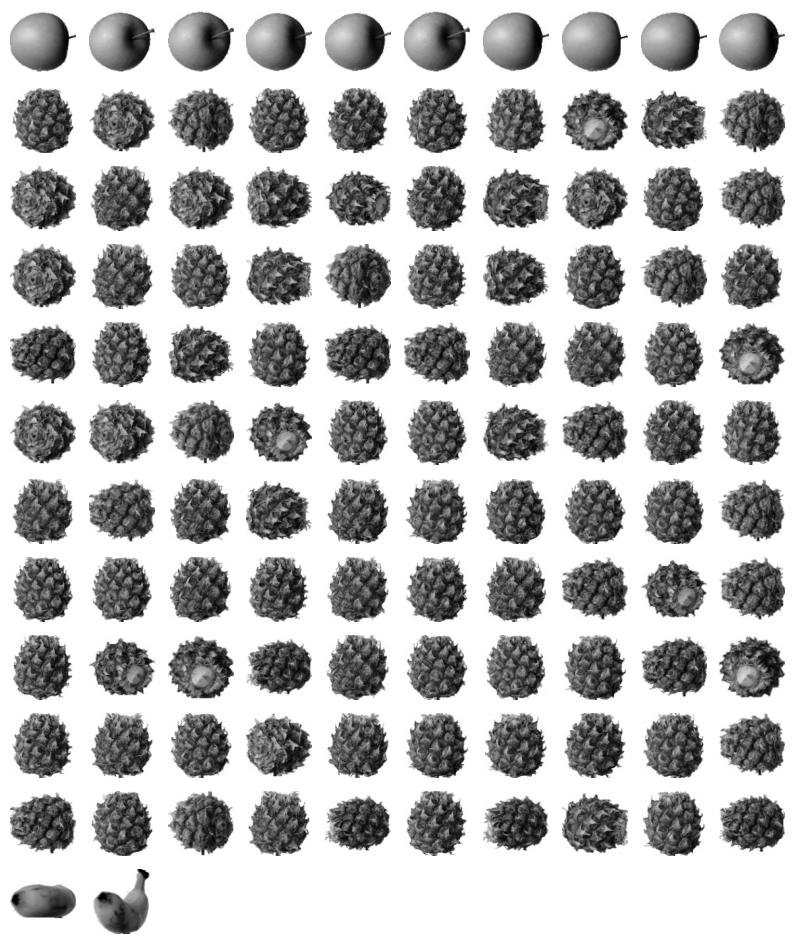

In [51]:
draw_fruits(fruits[km.labels_== 0])


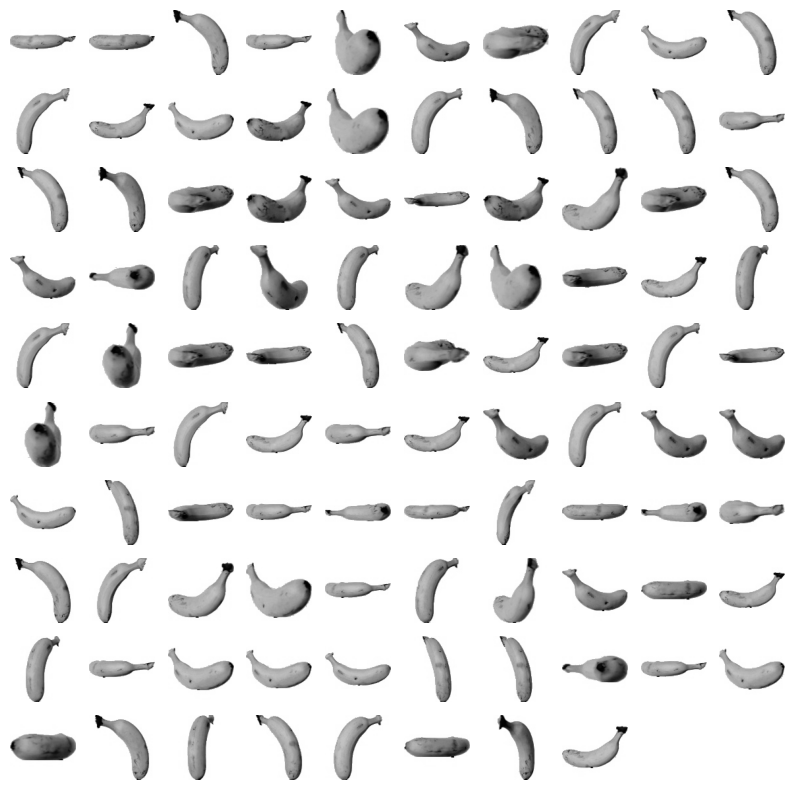

In [52]:
draw_fruits(fruits[km.labels_== 1])


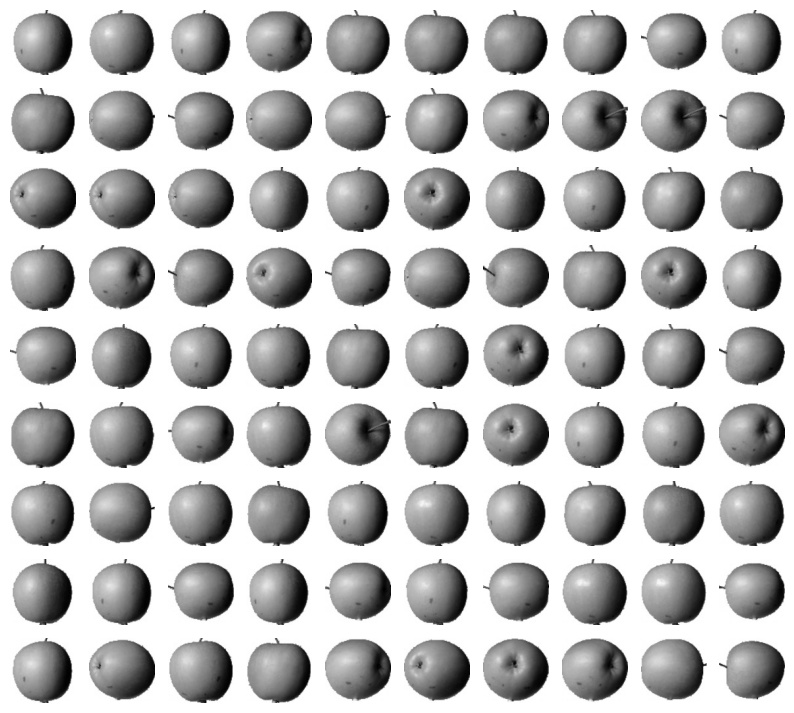

In [53]:
draw_fruits(fruits[km.labels_== 2])


## cluster_centers_  클러스터 중심

In [ ]:
# KMeans 클래스가 최종적으로 찾은 클러스터 중심은 cluster_centers_ 속성에 저장되어 있습니다.
# 이 배열을 fruits_2d 샘플의 클러스터 중심이기 때문에 이미지로 출력하려면 100 x 100 크기의
# 2차원 배열로 바꿔야 합니다.

In [55]:
# KMeans 클래스가 최종적으로 찾은 클러스터 중심은 cluster_centers_ 속성에 저장되어 있다
print(km.cluster_centers_.shape)

km.cluster_centers_

(3, 10000)


array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.10204082, 1.07142857, 1.10204082, ..., 1.        , 1.        ,
        1.        ],
       [1.01111111, 1.01111111, 1.01111111, ..., 1.        , 1.        ,
        1.        ]], shape=(3, 10000))

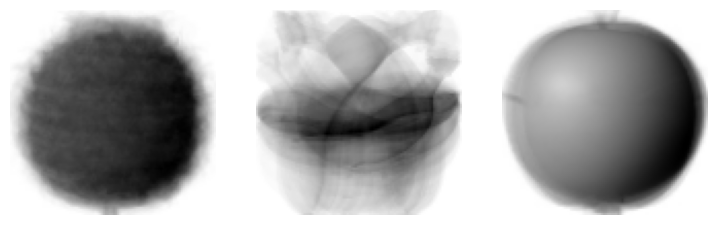

In [58]:
# ↑ fruits_2d 샘플의 클러스터 중심이다.

# 클러스터 중심을 시각화 하자
#   이미지로 출력하려면 100 x 100 으로 바꿔야 한다.

draw_fruits(km.cluster_centers_.reshape(-1,100,100), ratio=3)



## transform()
훈련데이터 샘플에서 클러스터 중심까지 거리로 변환

In [ ]:
# transform() :  훈련데이터 샘플에서 클러스터 중심까지 거리로 변환해 준다.
# 인덱스 100 인 샘플을 transform 적용해볼거다


In [59]:
# 인덱스 100 샘플의 shape 확인
fruits_2d[100].shape


(10000,)

In [61]:
# km.transform(fruits_2d[100]) <- 차원변화가 생기기때문에 에러

km.transform(fruits_2d[100:101])

array([[3400.24197319, 8837.37750892, 5279.33763699]])

In [62]:
# array([[3400.24197319, 8837.37750892, 5279.33763699]])
# 리턴된 값은 각각의 'cluster 갯수' 인 2차원 배열

## predict()

가장 가까운 클러스터 중심을 예측 클래스로 출력

In [63]:
# index 100 샘플의 가장 가까운 클러스터 중심 예측
km.predict(fruits_2d[100:101])

array([0], dtype=int32)

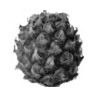

In [64]:
# 시각화 확인
draw_fruits(fruits[100:101])


## n_iter= 속성
'클러스터 중심' 이동을 반복했던 횟수

In [65]:
# k-평균 알고리즘은 앞에서 설명했듯이 반복적으로 클러스터 중심을 옮기면서 최적의 클러스터를 찾습니다.
# 알고리즘이 반복한 횟수는 KMeans 클래스의 n_iter_ 속성에 저장됩니다.

km.n_iter_

4

# 최적의 k 찾기

## n_clusters= 를 어떻게 지정?

In [ ]:
# n_clusters=3 으로 지정했다? <- 이미 타겟에 대한 정보를 활용한 셈이다...

# 실전의 데이터는 이러한 정보도 없을것이다.
# 과연 최적의 클러스터 개수는 어떻게 지정할 것인가?


In [ ]:
# 사실 군집 알고리즘에서 적절한 k 값을 찾기 위한 완벽한 방법은 없다.
# 다양한 방법은 있지만, 장단점들이 있다.
# 대표적인 방법인 엘보우(elbow) 방법을 소개합니다


## inertia (이너셔)

In [ ]:
# k-평균 알고리즘은 '클러스터 중심' 과 클러스터에 속한 샘플 사이의 거리를 잴 수 있다.
# 이 거리의 제곱 합을 이너셔 (inertia) 라 한다
# 이너셔는 클러스터에 속한 샘플이 얼마나 가깝게 모여 있는지 나타내는 값으로 활용할수 있다.

# 일반적으로 클러스터 개수가 늘어나면 클러스터 개개의 크기는 줄어들기 때문에 이너셔도 줄어듭니다.


## 엘보우(elbow) 방법

In [ ]:
# 엘보우 방법 : 클러스터의 개수를 늘려가면서
#             이니셔의 변화를 관찰하여 최적의 클러스터 개수를 찾는 방법

# 클러스터 개수를 증가시키면서 이너셔를 그래프로 그리면 감소하는 속도가 꺽이는 지점이 있다
# 이 지점부터는 클러스터 개수를 늘려도 클러스터에 잘 밀집된 정도가 크게 개선되지 않는다.



![](https://av-eks-blogoptimized.s3.amazonaws.com/62725cluster0.png)

In [ ]:
# KMeans 클래스의 inertia_ 속성:  자동으로 이너셔 계산


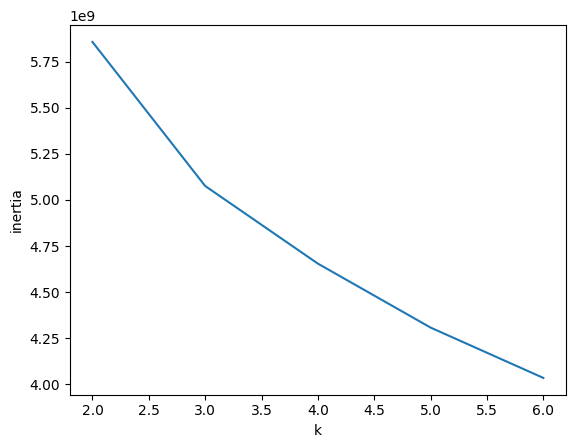

In [67]:
inertia = []
for k in range(2, 7): # 클러스터 개수를 2~6까지 바꿔가며  훈련
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(fruits_2d)
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

# 문제해결과정 : 과일을 자동으로 분류하기

1. 우선 과일 종류별로 픽셀 평균값을 계산
    - 그러나 실전에서는 어떤 과일 사진이 들어올지 모른다
    - 따라서 자동으로 사진을 클러스터로 모을 수 있는 군집 알고리즘이 필요
    
1. 대표적인 군집 알고리즘인 k-평균 알고리즘 사용. KMeans 클래스
    - 비교적 간단, 속도 빠르고, 이해하기 쉽다
    - 각 샘플이 어떤 클러스터에 소속되어 있는지 labels_속성에 저장
    
1. 각 샘플에서 각 클러스터까지의 거리를 하나의 특성으로 활용할 수도 있다
    - transform() 사용
    
1. predict() : 새로운 샘플에 대해 가장 가까운 클러스터를 예측값으로 출력
    
1. 최적의 클러스터 개수 k 알아내기 => 엘보우 방법
    - 이너셔 사용,
    - 이너셔가 더 이상 크게 줄어들지 않는다면 클러스터 개수를 더 늘리는 것은 효과가 없습니다
    - KMeans 에서 자동으로 이너셔 계산. inertia_ 속성 제공.

1. k-평균 알고리즘의 클러스터 중심까지 거리를 특성으로 사용할수도 있다.
    - 이를 통해, 훈련 데이터의 차원을 크게 줄일 수 있다.
    - 데이터 차원을 줄이면 지도 학습 알고리즘의 속도를 크게 높일수 있다.